In [2]:
# Conferir como as pastas estão organizadas nos arquivos ZIP
from zipfile import ZipFile

for nome in ["train", "val", "test"]:
    with ZipFile(f"/content/{nome}.zip") as arquivo:
        caminhos = [
            caminho for caminho in arquivo.namelist()
            if not caminho.startswith("__MACOSX/")
            and not caminho.endswith("/")
        ]

        print(f"\n{nome}.zip — primeiros arquivos:")
        for caminho in caminhos[:3]:
            print(caminho)


train.zip — primeiros arquivos:
train/frog_eye/tpdd__train_00305.jpg
train/frog_eye/tpdd__train_00311.jpg
train/frog_eye/tpdd__train_00339.jpg

val.zip — primeiros arquivos:
val/frog_eye/tpdd__validation_00022.jpg
val/frog_eye/tpdd__validation_00023.jpg
val/frog_eye/tpdd__validation_00027.jpg

test.zip — primeiros arquivos:
test/frog_eye/tpdd__test_00028.jpg
test/frog_eye/tpdd__test_00029.jpg
test/frog_eye/tpdd__test_00027.jpg


In [3]:
# Extrair as imagens para a pasta do dataset
from pathlib import Path
from zipfile import ZipFile

DATASET = Path("/content/SafraCerta_dataset")
DATASET.mkdir(parents=True, exist_ok=True)

for nome in ["train", "val", "test"]:
    with ZipFile(f"/content/{nome}.zip") as arquivo:
        for item in arquivo.infolist():
            partes = Path(item.filename).parts

            # Ignorar arquivos auxiliares do Mac
            if any(parte.startswith(".") or parte == "__MACOSX"
                   for parte in partes):
                continue

            # Manter a extração dentro da pasta do dataset
            destino = (DATASET / item.filename).resolve()
            if not destino.is_relative_to(DATASET.resolve()):
                raise ValueError(f"Caminho inválido: {item.filename}")

            arquivo.extract(item, DATASET)

    print(f"{nome}.zip extraído!")

print("\nExtração concluída:", DATASET)

train.zip extraído!
val.zip extraído!
test.zip extraído!

Extração concluída: /content/SafraCerta_dataset


In [4]:
# Contar imagens e classes de cada conjunto
from pathlib import Path

DATASET = Path("/content/SafraCerta_dataset")
EXTENSOES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for conjunto in ["train", "val", "test"]:
    pasta = DATASET / conjunto

    classes = [item for item in pasta.iterdir() if item.is_dir()]
    imagens = [
        item for item in pasta.rglob("*")
        if item.is_file() and item.suffix.lower() in EXTENSOES
    ]

    print(f"{conjunto}: {len(imagens)} imagens | {len(classes)} classes")

train: 1569 imagens | 16 classes
val: 225 imagens | 16 classes
test: 185 imagens | 16 classes


In [5]:
# Instalar a biblioteca Ultralytics para usar o YOLO
%pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.4 MB/s eta 0:00:00


In [6]:
# Verificar a biblioteca e a GPU
import ultralytics
import torch

print("Versão do Ultralytics:", ultralytics.__version__)
print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Versão do Ultralytics: 8.4.174
GPU disponível: True
Nome da GPU: Tesla T4


In [7]:
# Carregar o YOLO pré-treinado para classificação
from ultralytics import YOLO

modelo = YOLO("yolo26n-cls.pt")

print("Modelo carregado!")
print("Tarefa:", modelo.task)

Modelo carregado!
Tarefa: classify


In [8]:
# Treinar o modelo com as imagens de folhas de fumo
resultados = modelo.train(
    data="/content/SafraCerta_dataset",
    epochs=50,
    imgsz=224,
    batch=32,
    patience=10,
    device=0,
    workers=2,
    seed=42,
    project="/content/SafraCerta_resultados",
    name="yolo26n_classificacao",
    plots=True,
    save=True
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SafraCerta_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_classificacao, nbs=64, nms=None, opset=None, opti

In [9]:
# Salvar e baixar o modelo treinado, as métricas e os gráficos
from pathlib import Path
import shutil
from google.colab import files

pasta_resultados = Path(modelo.trainer.save_dir)

assert (pasta_resultados / "weights" / "best.pt").exists(), \
    "O melhor modelo ainda não foi salvo."

arquivo_zip = shutil.make_archive(
    "/content/SafraCerta_treinamento",
    "zip",
    root_dir=str(pasta_resultados)
)

files.download(arquivo_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from pathlib import Path
from ultralytics import YOLO

pasta_treino = Path(modelo.trainer.save_dir)
caminho_modelo = pasta_treino / "weights" / "best.pt"

assert caminho_modelo.exists(), "Arquivo best.pt não encontrado."

melhor_modelo = YOLO(str(caminho_modelo))

print("Modelo carregado:", caminho_modelo)
print("Classes:", melhor_modelo.names)

Modelo carregado: /content/SafraCerta_resultados/yolo26n_classificacao/weights/best.pt
Classes: {0: 'anthracnose', 1: 'black_shank', 2: 'brown_spot', 3: 'cmv', 4: 'frog_eye', 5: 'genetic_abnormality', 6: 'healthy', 7: 'nematodes', 8: 'potato_tuber_moth', 9: 'pvy', 10: 'sunscald', 11: 'target_spot', 12: 'tmv', 13: 'tswv', 14: 'weather_fleck', 15: 'wildfire'}


In [11]:
metricas_teste = melhor_modelo.val(
    data="/content/SafraCerta_dataset",
    split="test",
    imgsz=224,
    batch=32,
    device=0,
    workers=2,
    plots=True,
    project="/content/SafraCerta_resultados",
    name="avaliacao_teste"
)

pasta_teste = Path(metricas_teste.save_dir)

print(f"Acurácia Top-1: {metricas_teste.top1:.2%}")
print(f"Acurácia Top-5: {metricas_teste.top5:.2%}")
print("Resultados salvos em:", pasta_teste)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,546,520 parameters, 0 gradients, 3.2 GFLOPs
train: /content/SafraCerta_dataset/train... found 1569 images in 16 classes ✅ 
val: /content/SafraCerta_dataset/val... found 225 images in 16 classes ✅ 
test: /content/SafraCerta_dataset/test... found 185 images in 16 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2685.8±1744.3 MB/s, size: 762.6 KB)
test: Scanning /content/SafraCerta_dataset/test... 185 images, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185 4.8Kit/s 0.0s
test: New cache created: /content/SafraCerta_dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 2.3s/it 13.8s
                   all      0.832      0.995
Speed: 0.1ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/SafraCerta_resultados/avaliacao_teste
Acurácia Top-1: 83.24%
Acurácia Top-5: 99.46%
Resultados salvos

In [12]:
import pandas as pd

pasta_imagens = Path("/content/SafraCerta_dataset/test")
extensoes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

imagens_teste = sorted(
    caminho
    for caminho in pasta_imagens.rglob("*")
    if caminho.is_file() and caminho.suffix.lower() in extensoes
)

assert imagens_teste, "Nenhuma imagem de teste encontrada."

classes = [
    melhor_modelo.names[i]
    for i in range(len(melhor_modelo.names))
]

nome_para_id = {nome: i for i, nome in enumerate(classes)}
registros = []

previsoes = melhor_modelo.predict(
    source=[str(caminho) for caminho in imagens_teste],
    imgsz=224,
    batch=32,
    device=0,
    stream=True,
    verbose=False
)

for resultado in previsoes:
    caminho = Path(resultado.path)
    classe_real = caminho.parent.name

    assert classe_real in nome_para_id, \
        f"Classe desconhecida: {classe_real}"

    id_previsto = resultado.probs.top1

    registros.append({
        "imagem": str(caminho.relative_to(pasta_imagens)),
        "classe_real": classe_real,
        "classe_prevista": classes[id_previsto],
        "id_real": nome_para_id[classe_real],
        "id_previsto": id_previsto,
        "confianca": float(resultado.probs.top1conf.item())
    })

df_previsoes = pd.DataFrame(registros)

assert len(df_previsoes) == len(imagens_teste), \
    "A quantidade de previsões não corresponde às imagens."

df_previsoes.to_csv(
    pasta_teste / "previsoes_teste.csv",
    index=False
)

print("Imagens avaliadas:", len(df_previsoes))
display(df_previsoes.head())

Imagens avaliadas: 185


,imagem,classe_real,classe_prevista,id_real,id_previsto,confianca
0,anthracnose/tpdd__test_00000.jpg,anthracnose,frog_eye,0,4,0.990568
1,black_shank/roboflow__heijingbing-16-_jpg.rf.c...,black_shank,black_shank,1,1,0.995794
2,black_shank/roboflow__heijingbing-28-_jpg.rf.2...,black_shank,wildfire,1,15,0.670153
3,black_shank/roboflow__heijingbing-33-_jpg.rf.7...,black_shank,black_shank,1,1,0.835029
4,black_shank/roboflow__heijingbing-35-_jpg.rf.6...,black_shank,black_shank,1,1,0.995859


In [13]:
import json
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

y_real = df_previsoes["id_real"].to_numpy()
y_previsto = df_previsoes["id_previsto"].to_numpy()
ids_classes = list(range(len(classes)))

precisao, recall, f1, _ = precision_recall_fscore_support(
    y_real,
    y_previsto,
    labels=ids_classes,
    average="macro",
    zero_division=0
)

resumo = {
    "quantidade_imagens": len(df_previsoes),
    "acuracia": float(accuracy_score(y_real, y_previsto)),
    "precisao_macro": float(precisao),
    "recall_macro": float(recall),
    "f1_macro": float(f1),
    "top1_ultralytics": float(metricas_teste.top1),
    "top5_ultralytics": float(metricas_teste.top5)
}

for nome, valor in resumo.items():
    if nome == "quantidade_imagens":
        print(f"{nome}: {valor}")
    else:
        print(f"{nome}: {valor:.2%}")

relatorio = classification_report(
    y_real,
    y_previsto,
    labels=ids_classes,
    target_names=classes,
    output_dict=True,
    zero_division=0
)

df_relatorio = pd.DataFrame(relatorio).transpose()
display(df_relatorio.round(4))

df_relatorio.to_csv(pasta_teste / "metricas_por_classe.csv")

with open(pasta_teste / "resumo_metricas.json", "w",
          encoding="utf-8") as arquivo:
    json.dump(resumo, arquivo, indent=2, ensure_ascii=False)

quantidade_imagens: 185
acuracia: 83.24%
precisao_macro: 73.02%
recall_macro: 75.37%
f1_macro: 73.33%
top1_ultralytics: 83.24%
top5_ultralytics: 99.46%


,precision,recall,f1-score,support
anthracnose,0.0000,0.0000,0.0000,1.0000
black_shank,0.7500,0.8571,0.8000,7.0000
brown_spot,0.8333,1.0000,0.9091,10.0000
cmv,0.8125,0.8387,0.8254,31.0000
frog_eye,0.8333,1.0000,0.9091,10.0000
genetic_abnormality,0.5000,1.0000,0.6667,1.0000
healthy,0.8889,0.6667,0.7619,12.0000
nematodes,0.8571,0.7500,0.8000,8.0000
potato_tuber_moth,1.0000,0.9000,0.9474,10.0000
pvy,0.7500,0.6923,0.7200,13.0000


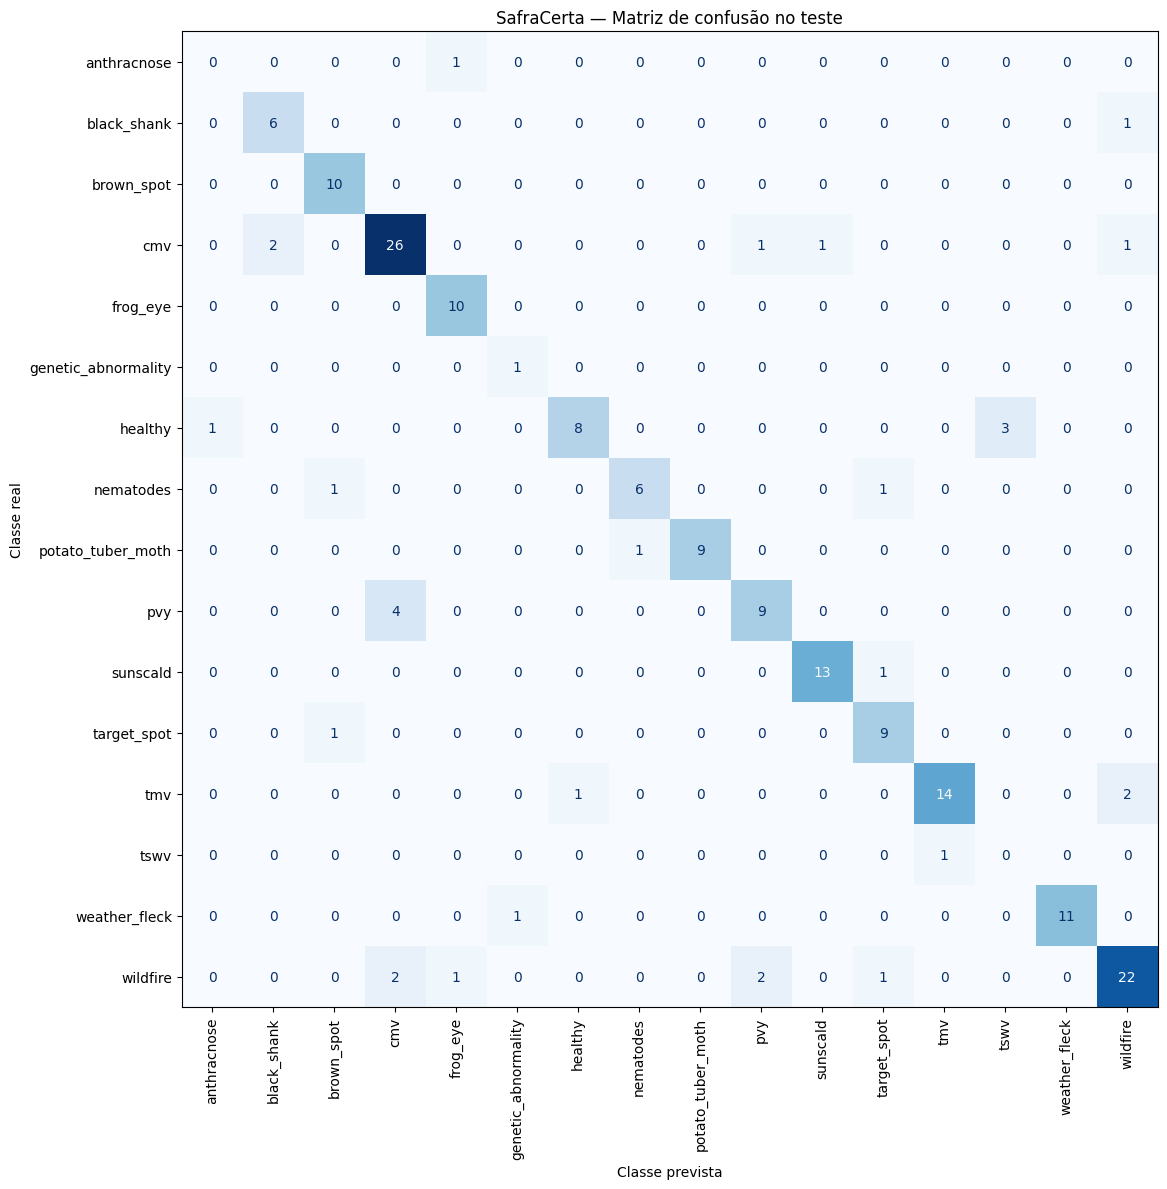

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz = confusion_matrix(
    y_real,
    y_previsto,
    labels=ids_classes
)

fig, ax = plt.subplots(figsize=(14, 12))

visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=classes
)

visualizacao.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

ax.set_title("SafraCerta — Matriz de confusão no teste")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
fig.savefig(
    pasta_teste / "matriz_confusao_teste.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

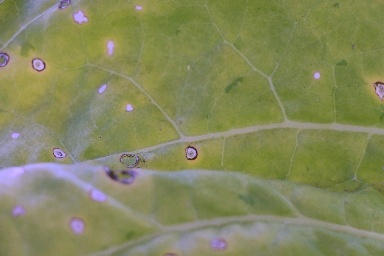

Classe real: anthracnose
Classe prevista: frog_eye
Confiança: 99.06%


In [15]:
from PIL import Image, ImageOps
from IPython.display import display

exemplo = df_previsoes.iloc[0]
caminho_exemplo = pasta_imagens / exemplo["imagem"]

with Image.open(caminho_exemplo) as imagem:
    imagem_exibicao = ImageOps.exif_transpose(imagem).convert("RGB")
    imagem_exibicao.thumbnail((600, 600))
    display(imagem_exibicao)

print("Classe real:", exemplo["classe_real"])
print("Classe prevista:", exemplo["classe_prevista"])
print(f"Confiança: {exemplo['confianca']:.2%}")

In [16]:
import shutil
from google.colab import files

pasta_entrega = Path("/content/SafraCerta_entrega")
pasta_entrega.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    pasta_treino,
    pasta_entrega / "treinamento",
    dirs_exist_ok=True
)

shutil.copytree(
    pasta_teste,
    pasta_entrega / "avaliacao_teste",
    dirs_exist_ok=True
)

arquivo_final = shutil.make_archive(
    "/content/SafraCerta_modelo_e_resultados",
    "zip",
    root_dir=str(pasta_entrega)
)

files.download(arquivo_final)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>